# Forecasting volatility with analogues

This tutorial forecasts Bitcoin's volatility over the next 24 hours from the *shape* of its recent
volatility, then opens up one forecast to see which historical episodes it was built from.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "font.size": 9})
BLUE, ORANGE, AQUA, INK2 = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"

In [2]:
import numpy as np, pandas as pd
from analogue_risk import volatility_forecast
from analogue_risk.data import binance

prices = binance("BTCUSDT", "1h")           # cached after the first download
prices.tail(3)

,open,high,low,close,volume
time,,,,,
2026-09-30 07:00:00,83043.14,83470.00,82956.11,83304.92,688.16580
2026-09-30 08:00:00,83304.92,83339.91,83023.69,83062.41,628.26691
2026-09-30 09:00:00,83062.41,83812.41,83058.00,83632.01,644.75388


`volatility_forecast` returns the forecast mean squared hourly log return over the next `horizon`
bars. With the default `kernel=True` it uses the recommended settings (Gaussian-kernel analogues
over the full history); `kernel=False` gives the paper's pre-registered kNN analogue.

In [3]:
vf = volatility_forecast(prices, horizon=24)
ok = vf.variance.notna() & (vf.realised > 0)
print(f"{ok.sum():,} forecasts; correlation of log forecast with log realised variance: "
      f"{np.corrcoef(np.log(vf.variance[ok]), np.log(vf.realised[ok]))[0, 1]:.2f}")
vf[ok].tail()

67,372 forecasts; correlation of log forecast with log realised variance: 0.63


,variance,log_variance,realised,n_analogues
time,,,,
2026-09-29 05:00:00,0.000008,-11.778804,0.000011,638.501541
2026-09-29 06:00:00,0.000010,-11.544208,0.000009,615.678483
2026-09-29 07:00:00,0.000008,-11.750593,0.000010,669.040120
2026-09-29 08:00:00,0.000010,-11.553161,0.000010,606.607570
2026-09-29 09:00:00,0.000010,-11.547900,0.000011,587.225019


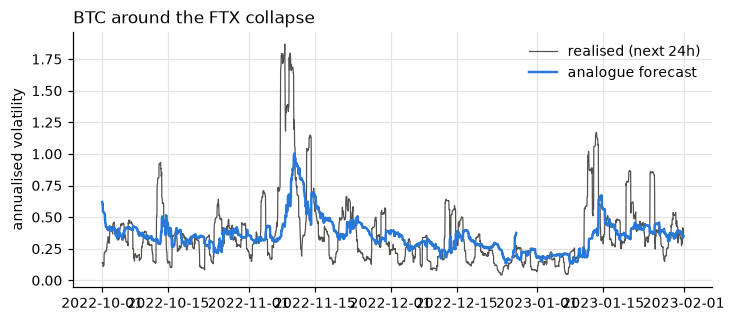

In [4]:
w = vf.loc["2022-10-01":"2023-01-31"]
ann = np.sqrt(24 * 365)  # hourly variance -> annualised volatility
fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(w.index, np.sqrt(w.realised) * ann, color=INK2, lw=0.8, label="realised (next 24h)")
ax.plot(w.index, np.sqrt(w.variance) * ann, color=BLUE, lw=1.6, label="analogue forecast")
ax.set_ylabel("annualised volatility"); ax.legend(frameon=False); ax.set_title("BTC around the FTX collapse", loc="left")
plt.show()

## Which past episodes is a forecast built from?

The general engine, `Analogue`, exposes the analogue set behind every forecast. Here we use the
paper's kNN analogue on the same volatility-shape embedding and look at the hour after FTX halted
withdrawals.

In [5]:
from analogue_risk import Analogue, model as M, vol as V

cfg = V.HOURLY                                   # the paper's configuration (h = 24, m = 4 segments)
d = V.VolData(M.Market(prices), cfg)
targets = d.target - np.log(d.long)              # log future variance relative to the long-run level
knn = Analogue(horizon=cfg.h, k=10, regime=False, min_history=cfg.warmup)
idx, w = knn.neighbours(d.emb, targets)

t = prices.index.get_loc(pd.Timestamp("2022-11-08 18:00"))
rows = [(prices.index[j], w[t, i], np.exp(targets[j])) for i, j in enumerate(idx[t]) if j >= 0]
pd.DataFrame(rows, columns=["analogue (start of window)", "weight", "future variance / long-run"]).round(2)

/var/folders/qf/bqc7cdbx06b91y10bxqbw3br0000gn/T/ipykernel_10772/2530323504.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  pd.DataFrame(rows, columns=["analogue (start of window)", "weight", "future variance / long-run"]).round(2)


,analogue (start of window),weight,future variance / long-run
0,2018-11-15 10:00:00,0.1,6.46
1,2019-11-22 13:00:00,0.1,0.82
2,2019-09-25 14:00:00,0.1,1.05
3,2021-09-07 18:00:00,0.1,1.10
4,2019-02-24 19:00:00,0.1,0.60
5,2020-07-27 23:00:00,0.1,3.25
6,2019-06-22 17:00:00,0.1,1.17
7,2020-03-09 13:00:00,0.1,1.49
8,2018-06-30 20:00:00,0.1,0.24
9,2018-04-13 09:00:00,0.1,0.47


Each row is a past hour whose preceding four days of volatility looked like the four days before
8 November 2022, and the last column is what happened to volatility over the following 24 hours.
The forecast is their weighted average, so it can be checked and argued with.